# Arc-Length Controlled Shape Design

Numerical demonstrations behind

> Bouwer, J. M., Kok, S. and Wilke, D. N. (2023). *Challenges and solutions to
> arc-length controlled structural shape design problems.* Mechanics Based Design of
> Structures and Machines, **51**(7), 4088–4119.
> [doi:10.1080/15397734.2021.1950549](https://doi.org/10.1080/15397734.2021.1950549)

Four things are shown here:

1. **Large arc-length steps pay for themselves** in solution time.
2. **A four-variable design space** — different design radii give different arches.
3. **Those arches solved with Q8 elements**, giving their load-deflection paths.
4. **The objective function** that compares a computed load path to a target one, with
   its analytical gradient — equation (9) of the paper, both interpolation schemes.

Running the optimisers on that objective, and the discontinuity study that motivates the
gradient-only ones, is the next piece and is not here yet.

> A full re-run takes a few minutes, most of it in section 4, where the two gradient
> evaluations each cost an arc-length solve carrying sensitivities. The notebook is
> committed with its output, so it reads without being executed.

In [2]:
import contextlib
import logging
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Mesh, Q8Mesh
from fem2d.postprocessing import Plotting
from fem2d.solvers import ArcLengthSolver

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # The solvers log every iteration; silence them for the sweeps.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## The structure

A deep circular arch spanning 270°, from −45° to 225°, clamped at one end and pinned at
the other. That is the paper's geometry. The asymmetry matters and is deliberate: it makes
the arch always deform towards the pinned side, which is the softer of the two, and it
unfolds what would otherwise be a symmetric buckling bifurcation into a smooth path
through a limit point.

**The section is a choice, not the paper's.** The paper publishes the geometry and the
design setup — radius 100 mm, design radii between 80 and 120 mm, the end radii held at
100 mm, and a cubic spline through them — but not the material constants. Here the radial
depth is set so that the section satisfies $EA = EI$,

$$\frac{I}{A} = \frac{h^2}{12} = 1 \;\Rightarrow\; h = \sqrt{12},$$

with $E = 210$ GPa and unit out-of-plane thickness. Absolute load factors are therefore
not the paper's.

They are, however, only a scale factor away from them. With a single elastic modulus the
residual is $R(u) = E f(u) - \lambda F$, where $f$ depends on the geometry and $\nu$
alone, so $\lambda = E f(u)/F$ is **linear in $E$**. And with $\psi = 0$ the arc-length
constraint is purely $\|\Delta U\|$, so the solver visits the same displacement states
whatever $E$ is. Changing $E$ stretches the load axis and does nothing else — the step
counts, the shape of every path, and the objective function (which is normalised by the
target's range) are all untouched. If the paper's peak load factor is known, $E$ can be
set to match it exactly.

In [31]:
h = 12**0.5
E = 210000.0                   # 210 GPa, in N and mm
v, t, plane = 0.3, 1.0, 0      # plane stress: a beam of unit width
R = 100.0                      # base radius, held at the two ends
Span = 270.0                   # the paper's arch, -45 to 225 degrees
Load = -1.0                    # unit point load at the crown, scaled by the load factor

def Arch(ElementType, el_num, radii):
    m = (Q8Mesh if ElementType == 'Q8' else Mesh)(E, v, t, plane, ElementType)
    m.SemiCircularArch(el_num, R, list(radii), h, Load, Span=Span)
    return m


# The Q8 sections below all use this mesh and these arc-length settings.
#
# The arc-length constraint is L**2 = dU.T @ dU summed over every free degree of
# freedom, so ||dU|| grows roughly as sqrt(ndof) and the same prescribed arc
# length covers less of the physical path on a finer mesh. Refining therefore
# means scaling the arc length by sqrt(ndof) as well, or the comparison is not
# like for like. The settings below were tuned at 12 elements and are carried
# up to 20 by that factor.
ElNum = 20

def FreeDof(el_num):
    # Q8 arch: 5*el_num + 3 nodes, of which 4 are held in both directions.
    return 10*el_num - 2

Scale = np.sqrt(FreeDof(ElNum)/FreeDof(12))
ArcStep, ArcTotal = 100.0*Scale, 1950.0*Scale

print(f'\nQ8 mesh: {ElNum} elements, {FreeDof(ElNum)} free dofs '
      f'({FreeDof(12)} at 12), scale {Scale:.4f}')
print(f'arc length {ArcStep:.2f}, total {ArcTotal:.1f}')


Q8 mesh: 20 elements, 198 free dofs (118 at 12), scale 1.2954
arc length 129.54, total 2526.0


20 elements, 103 nodes, 4 design variables


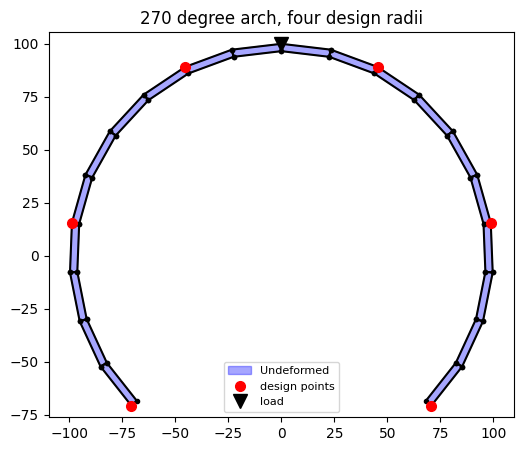

In [32]:
m = Arch('Q8', ElNum, [R]*4)

ax = Plotting.InitialMesh(m, alpha=0.35)
ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=7, label='design points')
ax.plot(m.Nodes[m.LoadNode//2, 1], m.Nodes[m.LoadNode//2, 2], 'kv', ms=10, label='load')
ax.set_title(f'{Span:.0f} degree arch, four design radii')
ax.legend(loc='lower center', fontsize=8)
ax.figure.set_size_inches(6, 5)
print(f'{m.Elements.shape[0]} elements, {m.Nodes.shape[0]} nodes, '
      f'{m.VariableNumber} design variables')

## 1. Why large arc-length steps pay

The arc-length method walks along the equilibrium path in fixed increments of arc length
rather than of load, which is what lets it round a limit point. The prescribed step is a
free choice, and when a step will not converge the solver halves it by $\sqrt{2}$ and
retries.

Small steps look safe but cost time. Large steps cover ground quickly but start to
trigger those retries. Sweeping the prescribed arc length on one fixed design shows both
ends of that trade.

In [33]:
class CountCuts(logging.Handler):
    # The solver logs a line whenever it reduces the arc step.
    def __init__(self):
        super().__init__()
        self.cuts = 0

    def emit(self, record):
        if 'cutting' in record.getMessage():
            self.cuts += 1


Total = 800.0
Sweep = [640.0, 320.0, 160.0, 80.0, 40.0, 20.0, 10.0]
Rows = []

for ArcLength in Sweep:
    Counter = CountCuts()
    SolverLog.handlers = [Counter]
    SolverLog.setLevel(logging.INFO)
    # The counter needs the records, but they must not also reach the root
    # handler, or every iteration lands in the notebook output.
    SolverLog.propagate = False

    m = Arch('5B', 20, [R]*4)
    Start = time.perf_counter()
    ArcLengthSolver(m, ArcLength=ArcLength, TotalArcLength=Total, tol=1e-6, MaxIter=9).Solve()
    Elapsed = time.perf_counter() - Start

    Lam = np.ravel(m.LoadValues)
    Rows.append((ArcLength, len(Lam) - 1, Counter.cuts, Elapsed, Lam.max()))

SolverLog.handlers = []
SolverLog.propagate = True

print(f"{'arc length':>11}{'steps':>7}{'cuts':>6}{'time (s)':>10}{'lambda max':>12}")
for ArcLength, Steps, Cuts, Elapsed, LamMax in Rows:
    print(f'{ArcLength:>11.1f}{Steps:>7}{Cuts:>6}{Elapsed:>10.2f}{LamMax:>12.1f}')

 arc length  steps  cuts  time (s)  lambda max
      640.0      7    34      7.57       235.7
      320.0      7    20      4.76       235.7
      160.0      7     6      2.22       235.7
       80.0     10     0      1.44       236.9
       40.0     21     3      2.42       237.2
       20.0     41     2      3.74       237.4
       10.0     80     0      6.47       237.4


`lambda max` barely moves across the sweep, so every run traced the same path and the
times are comparable.

The paper's Table 1 reports the same trend on its own arch, monotonically: step lengths
of 100, 50, 25, 12.5 and 6.25 took 26.2, 42.5, 53.7, 89.6 and 163.8 seconds. Halving the
step roughly doubles the cost.

What the sweep here adds is the other end of the curve. Past a point, a larger step stops
paying: the solver spends its time cutting back and retrying, so the cost turns round
again. The cheapest setting is the largest step that is *not* provoking many retries.

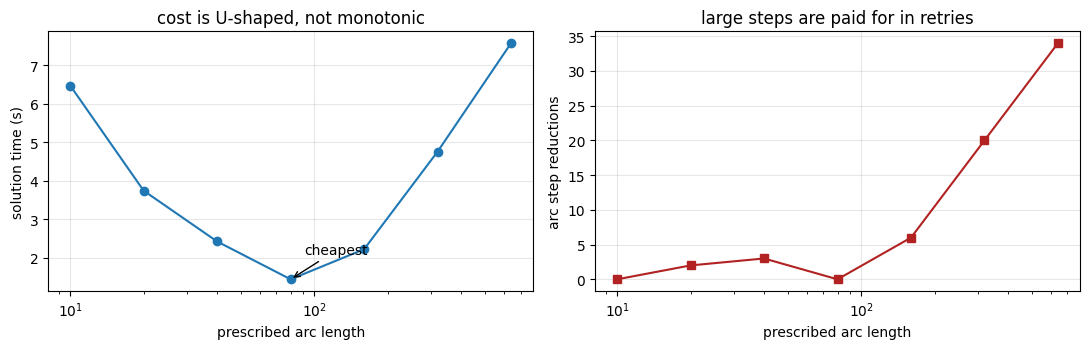

In [34]:
ArcLengths = [r[0] for r in Rows]
Times = [r[3] for r in Rows]
Cuts = [r[2] for r in Rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

a1.plot(ArcLengths, Times, 'o-')
a1.set(xscale='log', xlabel='prescribed arc length', ylabel='solution time (s)',
       title='cost is U-shaped, not monotonic')
a1.grid(alpha=0.3)
Best = int(np.argmin(Times))
a1.annotate('cheapest', xy=(ArcLengths[Best], Times[Best]),
            xytext=(10, 18), textcoords='offset points',
            arrowprops=dict(arrowstyle='->'))

a2.plot(ArcLengths, Cuts, 's-', color='firebrick')
a2.set(xscale='log', xlabel='prescribed arc length', ylabel='arc step reductions',
       title='large steps are paid for in retries')
a2.grid(alpha=0.3)
plt.tight_layout()

## 2. The four-variable design space

The shape parameters are the arch radius at four equally spaced angles. The two ends stay
at 100 mm and a cubic spline runs the radius through all six points, so a design is four
numbers and the arch follows.

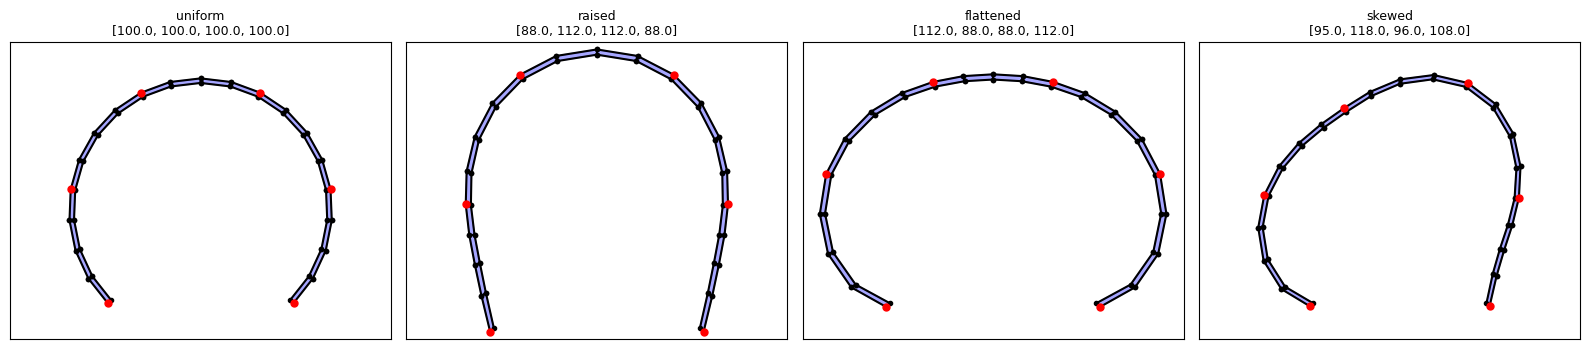

In [35]:
Designs = {
    'uniform':   [R, R, R, R],
    'raised':    [88.0, 112.0, 112.0, 88.0],
    'flattened': [112.0, 88.0, 88.0, 112.0],
    # The obvious skewed choice, 92 at the first station, cannot be traced: it
    # runs into a very sharp limit point at an accumulated arc length of 1088
    # that no amount of arc step cutting gets past. So do 91 and 93; 95 is fine.
    # The paper reports the same thing, that parts of this design space produce
    # load paths its solver could not follow.
    'skewed':    [95.0, 118.0, 96.0, 108.0],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (Name, radii) in zip(axes, Designs.items(), strict=True):
    m = Arch('Q8', ElNum, radii)
    Plotting.InitialMesh(m, ax=ax, alpha=0.35)
    ax.plot(m.VarPos[0], m.VarPos[1], 'ro', ms=5)
    ax.set_title(f'{Name}\n{radii}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 3. Load paths, solved with Q8

Each design is now traced with the arc-length solver using eight-node elements. The load
factor is plotted against the crown displacement, so the peak of each curve is the limit
point at which that arch snaps through.

**How far the path is traced is itself a modelling choice**, and it decides what the
figure shows. Every one of these arches snaps *back* eventually — the crown reverses while
the load keeps changing — but the reversal sits far out in the post-buckling tail, well
past the limit point, and how far varies with the design. At 215° the uniform arch reverses
about 50 mm past its limit point; at the 270° span used here it takes some 250 mm, by which
point the arch has inverted through itself. The prescribed total arc length decides which
side of that you see, which is why the cell below reports, rather than assumes, whether
each design turned back inside the window traced.

Arc-length control is what makes any of this reachable. Load control stops dead at the
limit point and displacement control cannot round a reversal at all.

In [36]:
Paths = {}
print(f"{'design':<11}{'steps':>6}{'time (s)':>10}{'limit load':>12}{'u at limit':>12}"
      f"{'u reached':>11}   turns back?")
for Name, radii in Designs.items():
    m = Arch('Q8', ElNum, radii)
    Start = time.perf_counter()
    with quiet():
        ArcLengthSolver(m, ArcLength=ArcStep, TotalArcLength=ArcTotal,
                        tol=1e-6, MaxIter=9).Solve()
    Paths[Name] = m

    Lam = np.ravel(m.LoadValues)
    U = m.AllU[m.LoadNode, :]
    Peak = int(np.argmax(Lam))
    # A reversal in the crown displacement is snap-back; report it from the data
    # rather than asserting it, since it depends on how far the path was traced.
    Back = np.flatnonzero(np.diff(U) > 0)
    Turns = (f'yes, {U[-1] - U.min():.1f} mm at u={U.min():.1f}' if len(Back)
             else 'no, not within this arc length')
    print(f'{Name:<11}{len(Lam)-1:>6}{time.perf_counter()-Start:>10.1f}{Lam.max():>12.1f}'
          f'{U[Peak]:>12.1f}{U.min():>11.1f}   {Turns}')

design      steps  time (s)  limit load  u at limit  u reached   turns back?
uniform        21       8.0       280.2      -110.5     -202.2   no, not within this arc length
raised         21       6.6       209.3      -101.3     -213.8   no, not within this arc length
flattened      30      17.6       383.9      -207.5     -207.5   no, not within this arc length
skewed         20       6.3       193.4       -99.6     -219.5   no, not within this arc length


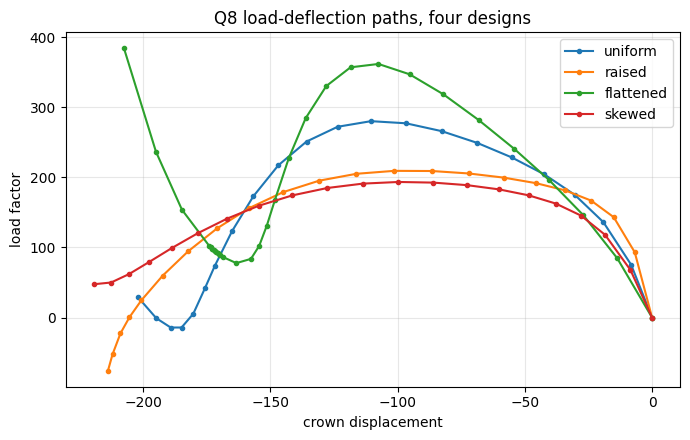

In [37]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for Name, m in Paths.items():
    ax.plot(m.AllU[m.LoadNode, :], np.ravel(m.LoadValues), 'o-', ms=3, label=Name)
ax.set(xlabel='crown displacement', ylabel='load factor',
       title='Q8 load-deflection paths, four designs')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

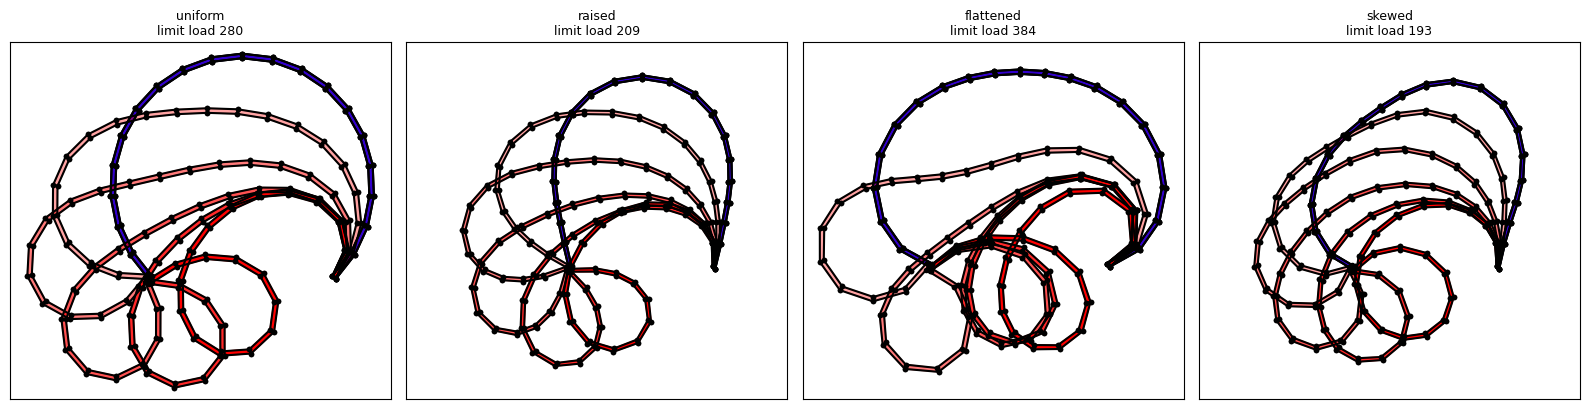

In [38]:
# The deformed shapes behind the four load paths above, faded in step by step.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (Name, m) in zip(axes, Paths.items(), strict=True):
    Plotting.Overlay(m, ax=ax, steps=max(1, m.AllU.shape[1]//5))
    ax.set_title(f'{Name}\nlimit load {np.ravel(m.LoadValues).max():.0f}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 4. The objective function

Given a *target* load path, the inverse problem is to find the design radii that reproduce
it. That needs a number measuring how far apart two load paths are — and the two curves
are not sampled at the same places, because the arc-length solver returns its solutions at
whatever accumulated arc lengths its stepping happens to land on.

The paper's answer is to treat both as **parametric curves in accumulated arc length** and
interpolate linearly, which leaves a choice the analyst has to make:

- **objective function A** — interpolate the *target* onto the design's arc lengths,
- **objective function B** — interpolate the *design* onto the target's arc lengths.

Either way the error is the mean squared error, the paper's equation (9), over the load
factor $\lambda$ and the crown displacement $u$:

$$\mathrm{MSE} = \frac{1}{N}\sum_i^N (\lambda^T_i - \lambda^d_i)^2
              + \frac{1}{N}\sum_i^N (u^T_i - u^d_i)^2$$

with $N$ the number of solution steps taken (A) or the number of points describing the
target (B). Load and displacement differ by an order of magnitude, so both are scaled by
the target curve's range first, which is what the paper does so that the two weigh
equally.

### Why the gradient is straightforward, and where the discontinuity comes from

Differentiating gives equation (10),

$$\frac{d\,\mathrm{MSE}}{dx} = -\frac{2}{N}\sum_i^N (\lambda^T_i - \lambda^d_i)
  \frac{d\lambda^d_i}{dx} - \frac{2}{N}\sum_i^N (u^T_i - u^d_i)\frac{du^d_i}{dx}$$

which needs the derivatives of the interpolated quantities — and therefore of the
accumulated arc lengths the interpolation is built on. Those turn out to be free. The
solver *enforces* $\|\Delta U\|^2 + \psi^2 \Delta\lambda^2 = \ell_k^2$ at every step, with
$\ell_k$ the prescribed arc length divided by $\sqrt2$ once per cut. The arc length
reached at step $k$ is therefore a fixed number, **independent of the design**, so
$ds_k/dx = 0$ and the interpolation weights are constants in the gradient.

That is exactly true — until the *cut pattern* changes. One infinitesimal change in a
radius can trigger one more retry, which shifts every subsequent sample point and changes
how many there are. The objective then jumps, while the gradient stays perfectly
well-defined on either side. This is the paper's central observation and the reason it
reaches for gradient-only optimisers.

In [39]:
# Every objective evaluation is an arc-length solve, and every gradient is one carrying
# sensitivities, which costs about five times as much again. This section therefore uses
# 5B elements at the cheapest setting section 1 found, rather than the Q8 mesh above.
ObjElNum, ObjArc, ObjTotal = 20, 40.0, 800.0


def Curve(radii, Sensitivity=True):
    """Solve one design and return its load path parametrised by accumulated arc length."""
    m = Mesh(E, v, t, plane, '5B')
    m.SemiCircularArch(ObjElNum, R, list(radii), h, Load, Span=Span)
    with quiet():
        ArcLengthSolver(m, ArcLength=ObjArc, TotalArcLength=ObjTotal,
                        tol=1e-6, MaxIter=9, Sensitivity=Sensitivity).Solve()

    s = m.ArcValues                 # accumulated arc length, one per stored point
    u = m.AllU[m.LoadNode, :]       # crown displacement (LoadNode is already the y dof)
    lam = np.ravel(m.LoadValues)    # load factor

    if not Sensitivity:
        return s, u, lam, None, None

    # dUdx_All and dLdx hold one entry per arc step, so they are one shorter than AllU.
    # Row 0 is the undeformed state, which no design variable moves.
    Zero = np.zeros((1, m.VariableNumber))
    dU = np.vstack((Zero, np.atleast_3d(m.dUdx_All)[m.LoadNode, :, :].T))
    dLam = np.vstack((Zero, m.dLdx))
    return s, u, lam, dU, dLam


def Interp(s, y, dy, At):
    """Linear interpolation of y(s) onto At, and of dy/dx through the same weights.

    The weights are constants in the gradient because ds/dx is zero: the solver
    holds the arc length of each step to a prescribed value.
    """
    k = np.clip(np.searchsorted(s, At, side='right') - 1, 0, len(s) - 2)
    w = (At - s[k])/(s[k+1] - s[k])
    Value = (1 - w)*y[k] + w*y[k+1]
    Grad = None if dy is None else (1 - w)[:, None]*dy[k] + w[:, None]*dy[k+1]
    return Value, Grad

In [40]:
class Objective:
    """Equations (9) and (10) of the paper, both interpolation schemes, off one solve.

    Calling it returns ((fA, gA), (fB, gB)). The target is the fully symmetrical
    arch, so the global optimum is known: zero, at the target radii themselves.
    """

    def __init__(self, TargetRadii):
        self.sT, self.uT, self.lamT, _, _ = Curve(TargetRadii, Sensitivity=False)
        # Load and displacement differ in magnitude, so scale both by the target
        # range and they weigh equally. Offsets cancel in a difference.
        self.ScaleLam = np.ptp(self.lamT)
        self.ScaleU = np.ptp(self.uT)
        self.Steps = len(self.sT) - 1

    def _MSE(self, ResLam, ResU, dLam, dU):
        N = len(ResLam)
        f = np.mean(ResLam**2) + np.mean(ResU**2)
        if dLam is None:
            return f, None
        Grad = -2*(ResLam @ dLam/self.ScaleLam + ResU @ dU/self.ScaleU)/N
        return f, Grad

    def __call__(self, radii, Sensitivity=True):
        s, u, lam, dU, dLam = Curve(radii, Sensitivity)

        # How many arc steps this design took. Watch it: when it changes, the
        # sample points move and the objective jumps.
        self.Steps = len(s) - 1

        # A: interpolate the TARGET onto this design's own arc lengths. Nothing is
        # interpolated on the design side, so the raw sensitivities are used. N is
        # this design's step count, which is what changes at a discontinuity.
        Keep = s[1:] <= self.sT[-1]
        At = s[1:][Keep]
        LamT, _ = Interp(self.sT, self.lamT, None, At)
        UT, _ = Interp(self.sT, self.uT, None, At)
        A = self._MSE((LamT - lam[1:][Keep])/self.ScaleLam,
                      (UT - u[1:][Keep])/self.ScaleU,
                      None if dLam is None else dLam[1:][Keep],
                      None if dU is None else dU[1:][Keep])

        # B: interpolate this DESIGN onto the target's arc lengths, which are fixed,
        # so N and the sample locations never change.
        KeepB = self.sT[1:] <= s[-1]
        AtB = self.sT[1:][KeepB]
        LamD, dLamD = Interp(s, lam, dLam, AtB)
        UD, dUD = Interp(s, u, dU, AtB)
        B = self._MSE((self.lamT[1:][KeepB] - LamD)/self.ScaleLam,
                      (self.uT[1:][KeepB] - UD)/self.ScaleU, dLamD, dUD)

        return A, B


MSE = Objective([R]*4)   # the fully symmetrical arch is the target

print(f'target: {MSE.Steps} steps, arc length {MSE.sT[-1]:.1f}')
print(f'        load factor range {MSE.ScaleLam:.1f}, displacement range {MSE.ScaleU:.2f}')
print(f'        arc steps {np.round(np.diff(MSE.sT), 2)}')
print(f'\nThe first steps are shorter than the prescribed {ObjArc:.0f}: those are the retries.')

target: 21 steps, arc length 808.3
        load factor range 237.2, displacement range 126.70
        arc steps [40.   20.   28.28 40.   40.   40.   40.   40.   40.   40.   40.   40.
 40.   40.   40.   40.   40.   40.   40.   40.   40.  ]

The first steps are shorter than the prescribed 40: those are the retries.


In [41]:
# At the target itself the objective must be exactly zero, and so must its gradient.
(fA, gA), (fB, gB) = MSE([R]*4)
print(f'at the target   A: f = {fA:.3e}   |g| = {np.linalg.norm(gA):.3e}')
print(f'                B: f = {fB:.3e}   |g| = {np.linalg.norm(gB):.3e}')

# And at a design that is off it.
x0 = np.array([100.0, 105.0, 98.0, 102.0])
(fA, gA), (fB, gB) = MSE(x0)
print(f'\nat {x0}')
print(f'   A: f = {fA:.8f}')
print(f'      g = {np.array2string(gA, precision=8)}')
print(f'   B: f = {fB:.8f}')
print(f'      g = {np.array2string(gB, precision=8)}')

at the target   A: f = 0.000e+00   |g| = 0.000e+00
                B: f = 0.000e+00   |g| = 0.000e+00

at [100. 105.  98. 102.]
   A: f = 0.00254985
      g = [2.09787885e-05 7.03764814e-04 2.22614237e-04 1.02059190e-03]
   B: f = 0.00262293
      g = [2.46510787e-05 6.98975496e-04 2.18061347e-04 1.03753087e-03]


### Checking the gradient

Central differences on one design variable, with the step swept. The stiffness matrices
here have condition numbers around $10^6$, so a single fixed step proves nothing: too
large and truncation error dominates, too small and cancellation does.

The table also reports how many arc steps each perturbed design took, which is the thing
to watch. When the two disagree, the difference has straddled a change in the cut
pattern — a discontinuity — and the finite difference is then wrong in both magnitude and
sign, exactly as the paper warns. The analytical gradient is unaffected, being the
derivative of the branch actually taken.

Whether that happens depends on where in the design space you are and how the arc stepping
falls, so the cell reports it rather than assuming it. At the 215° span this same check
straddled a discontinuity at the two largest steps and the finite difference came out
wrong by one to two orders of magnitude.

The paper reports its analytical and forward-difference gradients agreeing to six
significant figures at a perturbation of $10^{-6}$.

In [42]:
Var = 1   # one variable is enough: each finite difference costs two more solves
Base = MSE.Steps
Straddled = False

print(f'analytic  A {gA[Var]: .10f}    B {gB[Var]: .10f}')
print(f'the design at x0 takes {Base} arc steps\n')
print(f"{'step':>8}{'steps -/+':>11}{'central FD, A':>16}{'rel err':>10}"
      f"{'central FD, B':>16}{'rel err':>10}")

for Step in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    xp, xm = x0.copy(), x0.copy()
    xp[Var] += Step
    xm[Var] -= Step
    (fAm, _), (fBm, _) = MSE(xm, Sensitivity=False)
    StepsM = MSE.Steps
    (fAp, _), (fBp, _) = MSE(xp, Sensitivity=False)
    StepsP = MSE.Steps
    FDA, FDB = (fAp - fAm)/(2*Step), (fBp - fBm)/(2*Step)
    Same = StepsM == StepsP == Base
    Straddled = Straddled or not Same
    Flag = '' if Same else '*'
    Counts = f'{StepsM}/{StepsP}{Flag}'
    print(f'{Step:>8.0e}{Counts:>11}'
          f'{FDA:>16.10f}{abs(FDA - gA[Var])/abs(gA[Var]):>10.1e}'
          f'{FDB:>16.10f}{abs(FDB - gB[Var])/abs(gB[Var]):>10.1e}')

if Straddled:
    print('\n* the two perturbed designs did not take the same number of arc steps,')
    print('  so that difference straddles a discontinuity and the FD is not to be trusted.')
else:
    print('\nEvery perturbation took the same number of arc steps as the design itself,')
    print('so none of these differences crossed a discontinuity and all of them agree.')

analytic  A  0.0007037648    B  0.0006989755
the design at x0 takes 20 arc steps

    step  steps -/+   central FD, A   rel err   central FD, B   rel err
   1e-01      20/20    0.0007037624   3.4e-06    0.0006989728   3.9e-06
   1e-02      20/20    0.0007037649   1.0e-07    0.0006989756   9.3e-08
   1e-03      20/20    0.0007037649   1.4e-07    0.0006989756   1.3e-07
   1e-04      20/20    0.0007037649   1.6e-07    0.0006989756   1.6e-07
   1e-05      20/20    0.0007037648   5.0e-08    0.0006989755   5.3e-08
   1e-06      20/20    0.0007037631   2.4e-06    0.0006989738   2.5e-06

Every perturbation took the same number of arc steps as the design itself,
so none of these differences crossed a discontinuity and all of them agree.


### The two schemes, drawn

Both curves in the arc-length space the objective works in, with the sample points each
scheme uses. Where the two solves took different numbers of steps, or took them at
different arc lengths because one of them cut and the other did not, the crosses and the
plusses land in different places — and that is the whole mechanism behind the
discontinuities.

target has 21 steps, this design has 20
The error is summed at the crosses for A and at the plusses for B.


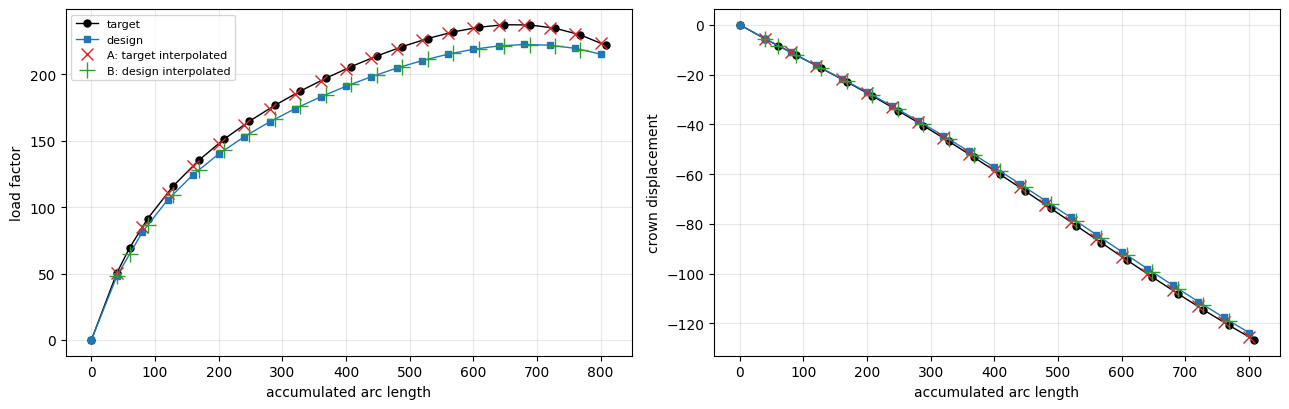

In [43]:
# The two schemes drawn out, in the arc-length space the objective works in.
s, u, lam, _, _ = Curve(x0, Sensitivity=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (yT, yD, Name) in zip(axes,
                              ((MSE.lamT, lam, 'load factor'),
                               (MSE.uT, u, 'crown displacement')), strict=True):
    ax.plot(MSE.sT, yT, 'o-', color='k', ms=5, lw=1, label='target')
    ax.plot(s, yD, 's-', color='tab:blue', ms=5, lw=1, label='design')

    # A samples at the design's arc lengths, interpolating the target onto them.
    At = s[1:][s[1:] <= MSE.sT[-1]]
    ax.plot(At, Interp(MSE.sT, yT, None, At)[0], 'x', color='tab:red', ms=9,
            label='A: target interpolated')

    # B samples at the target's, interpolating the design onto them.
    AtB = MSE.sT[1:][MSE.sT[1:] <= s[-1]]
    ax.plot(AtB, Interp(s, yD, None, AtB)[0], '+', color='tab:green', ms=11,
            label='B: design interpolated')

    ax.set(xlabel='accumulated arc length', ylabel=Name)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()

print(f'target has {len(MSE.sT)-1} steps, this design has {len(s)-1}')
print('The error is summed at the crosses for A and at the plusses for B.')

### What this sets up

The objective and its gradient are the input to the optimisation half of the paper, which
is next and is not here yet:

- **the discontinuity study** — sampling the objective along one design variable between
  radii of 80 and 120 mm, which is the paper's Figure 9, and the dense line search through
  a single discontinuity that is its Figure 10. Objective A jumps hardest; B softens the
  jumps but does not remove them;
- **the optimiser comparison** — SLSQP against two gradient-only methods, GOSSA and a
  Modified Subgradient method. The paper's finding is that SLSQP mistakes a discontinuity
  for a minimum and stops early, while the gradient-only methods walk through it, because
  the *gradient* stays well behaved even where the function value does not.

**The optimisers.** GOSSA comes from `pmo.py`, the module accompanying Snyman and Wilke,
*Practical Mathematical Optimization* (2nd ed., Springer 2018). It is a single file rather
than a package, its original home at `extras.springer.com` now returns 404, and it is
Springer copyright, so it is deliberately not vendored here. It exposes `gossa`, `gosda`
and `bfgsgo` as `scipy.optimize.minimize(method=...)` plug-ins, so the `Objective` above
drops straight in. The Modified Subgradient method needs nothing external — the paper
describes it as steepest descent with a fixed step and no line search, and no memory of
the best point seen.

**What a gradient costs.** Table 3 of the paper reports the analytical sensitivity taking
about 48 seconds whether there are 1, 2, 4, 8 or 16 design variables, against forward
differences growing from 54 to 459. The point is that the analytical cost does not scale
with the number of design variables, and this implementation now shares that property:

| design variables | 1 | 2 | 4 | 8 |
|---|---|---|---|---|
| 5β arc-length solve with sensitivities (s) | 12.4 | 13.3 | 12.9 | 13.3 |

It did not until recently, and the reason is worth recording. `Solver._dRdXVariable`
integrated each element once per moved nodal co-ordinate *per design variable*, and since
the radius spline moves every node, that was essentially the whole cost — 99% of a
sensitivity step, against 0.1 ms for the factorisation and an unmeasurable back
substitution.

The fix is a reassociation of the chain rule rather than a new algorithm. Writing

$$\frac{\partial R}{\partial x_j} = \sum_a \frac{\partial R}{\partial X_a}
  \frac{\partial X_a}{\partial x_j},$$

the element integral $\partial R/\partial X_a$ depends on the element and its local degree
of freedom alone; the design variable enters only through the scalar weight
$\partial X_a/\partial x_j$. Integrating once per (element, local dof) and contracting
against every variable afterwards gives the same numbers **to the last bit** at a cost
independent of the variable count. On top of that the Jacobian is now kept per quadrature
point rather than rebuilt and inverted afresh each time it is asked for — it was being
inverted about seventy times per Gauss point.

Together those took a 5β sensitivity solve from 83 s to 16.5 s and a plain solve from
6.5 s to 3.3 s.

This is *not* the adjoint method, which is the usual answer to cost scaling with design
variables. The adjoint replaces one linear solve per variable with a single adjoint solve,
and here those solves were already free. It would also not fit comfortably: the arc-length
recursion needs the full $dU/dx$ field at each step to carry into the next step's
constraint, so there is nothing to contract to a scalar step by step. A genuine adjoint
would have to be a reverse sweep over the whole traced path — and it still would not avoid
the $\partial R/\partial X$ integrals, which are where the time actually goes.

## Caveat on the limit load

The peak load factor is **not fully mesh converged**. Refining along the arch for the
uniform design with 5β elements gives:

| elements | free dofs | λ max, fixed arc length | λ max, arc length scaled by √ndof |
|---|---|---|---|
| 20 | 78 | 237.2 | 237.2 |
| 40 | 158 | 184.5 | 184.7 |
| 60 | 238 | 177.3 | 180.8 |

It is settling — down 22% from 20 to 40 elements, then only 4% from 40 to 60 — but 20
elements, which is what the sections above use, overestimates by about a third.

It is ordinary discretisation error, not an artefact of the solver. Scaling the arc length
with `sqrt(ndof)` on refinement, which would matter if the constraint's dependence on the
degree-of-freedom count were responsible, changes the answer by under 2%. Refining the arc
length on a *fixed* mesh converges cleanly, and sharing the crown load across the section
rather than applying it at a point moves it by under 0.1%. What is left is the element: 5β
is a low-order element and a deep arch rotating this far simply needs a lot of them.

Nothing above depends on it. The arc-length sweep holds the mesh fixed and varies only the
step; the design comparison holds the mesh fixed and varies only the shape; and the
objective function compares two curves computed on the same mesh with the same settings.
But the limit loads should be read as relative to one another, not as converged values.